In [1]:
import torch
import pickle
from torch import nn
from tqdm import tqdm
from mydataloader2 import *
from animation_marking import animation_double
from seq2seq import Seq2Seq

In [2]:
with open(r"E:\bishe\work\results\posearray.pkl","rb")as f:
    circular=pickle.load(f)


In [3]:
batch_size = 64
train_steps = 20
input_size = 6
de_input_size = 3
hidden_size = 256
linear_size = 128
output_size = 3
lr = 0.005
num_layer = 2
pred_steps = 10
test_num = 20
train_ratio = 0.8
epochs = 100
type = "lstm"

scaler = StandardScaler()
scaler.fit(circular)
circular_trans=scaler.transform(circular)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_loder=MyDataLoader(circular_trans,train_ratio,test_num,batch_size,train_steps,pred_steps)
net=Seq2Seq(input_size,de_input_size,hidden_size,output_size,num_layer,linear_size,pred_steps,train_steps,type).to(device)


In [4]:
# net = torch.load("model.pth", map_location=device, weights_only=False)
net.load_state_dict(
    torch.load("time_seq_best.opt", map_location=device, weights_only=False)
)

<All keys matched successfully>

In [5]:
test_loder=data_loder.test_iter(6)
mutil_steps_pred=pred_time_seq(test_loder,net,device,test_num,num_layer,hidden_size)
mutil_steps_pred=scaler.inverse_transform(mutil_steps_pred,train_steps,pred_steps,output_size,test_num)
print(mutil_steps_pred[0].shape)

(111, 10, 3)


In [6]:
mutil_steps_pred[0][25]

array([[36.53068204, 31.30364922,  7.98647342],
       [36.67006166, 31.10275616,  7.96115423],
       [36.79968378, 30.99804125,  7.96451478],
       [36.97255788, 30.95584922,  7.97944739],
       [37.15786576, 30.89609996,  8.00106318],
       [37.36137508, 30.85581533,  8.03920997],
       [37.58464246, 30.83647367,  8.08690754],
       [37.82915077, 30.83369457,  8.14352129],
       [38.08585801, 30.85007404,  8.21355142],
       [38.33659823, 30.88084361,  8.29064366]])

In [7]:
circular[5073+0][40:50,1:4]


array([[38.53421118, 30.70399213,  9.02071424],
       [38.66689552, 30.77435614,  9.1606513 ],
       [38.78082113, 30.85143486,  9.29373751],
       [38.88685154, 30.94274168,  9.43550648],
       [38.97014238, 31.0402968 ,  9.56516165],
       [39.04433839, 31.15440687,  9.70435415],
       [39.0975255 , 31.26481991,  9.83306848],
       [39.13840157, 31.38847837,  9.9740331 ],
       [39.15755636, 31.50805193, 10.0937644 ],
       [39.16036107, 31.64110093, 10.21501361]])

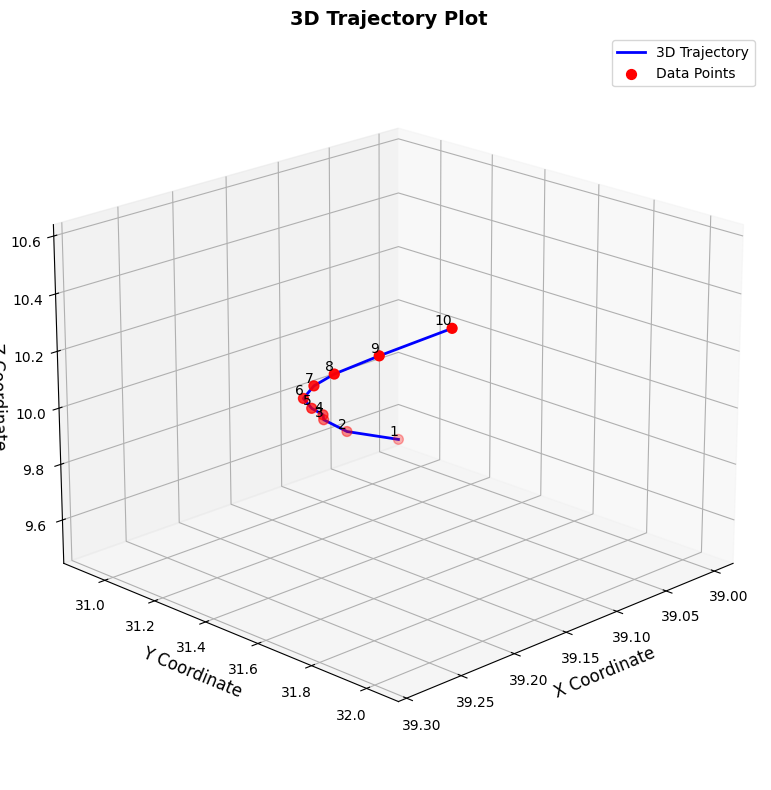

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

data = mutil_steps_pred[0][44]

# 分离x, y, z坐标
x = data[:, 0]
y = data[:, 1]
z = data[:, 2]

# 创建3D图形
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制轨迹线
ax.plot(x, y, z, 'b-', linewidth=2, label='3D Trajectory')

# 绘制数据点
ax.scatter(x, y, z, c='red', s=50, marker='o', label='Data Points')

# 标注每个点的序号
for i, (xi, yi, zi) in enumerate(zip(x, y, z)):
    ax.text(xi, yi, zi, f'{i+1}', fontsize=10, ha='right', va='bottom')

# 设置坐标轴标签
ax.set_xlabel('X Coordinate', fontsize=12)
ax.set_ylabel('Y Coordinate', fontsize=12)
ax.set_zlabel('Z Coordinate', fontsize=12)

# 设置标题
ax.set_title('3D Trajectory Plot', fontsize=14, fontweight='bold')

# 添加图例
ax.legend()

# 设置视角（可选，调整为更好的观察角度）
ax.view_init(elev=20, azim=45)

# 显示网格
ax.grid(True)

# 显示图形
plt.tight_layout()
plt.show()

Total frames: 111


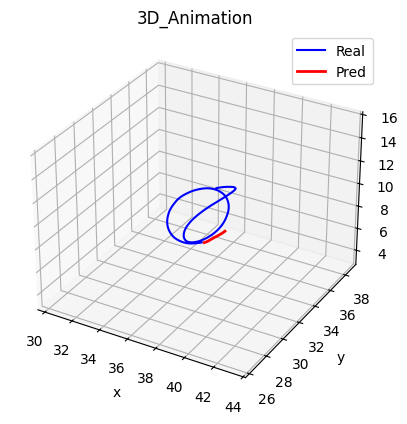

Total frames: 169


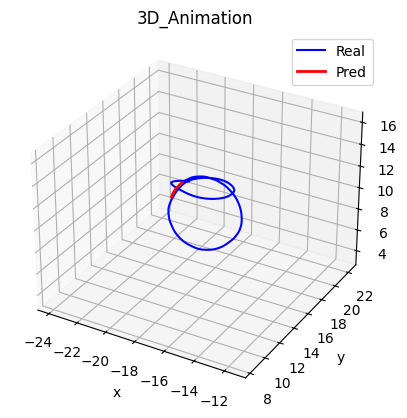

Total frames: 128


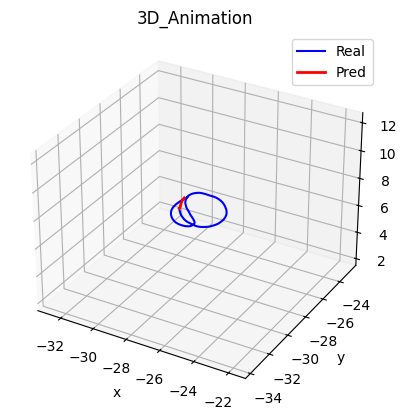

Total frames: 120


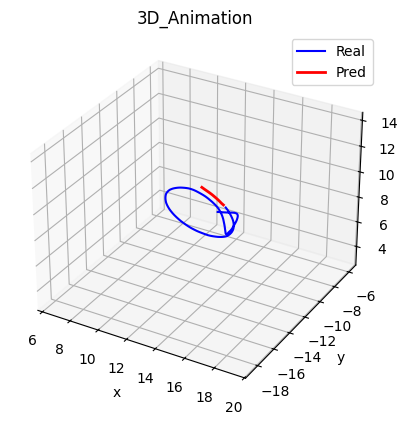

Total frames: 100


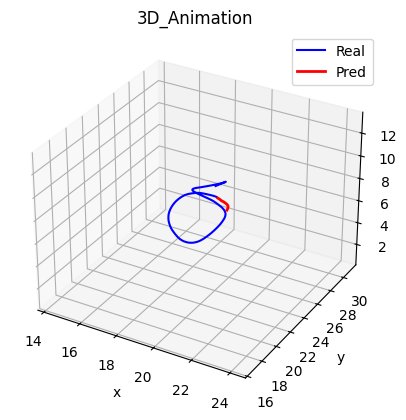

Total frames: 127


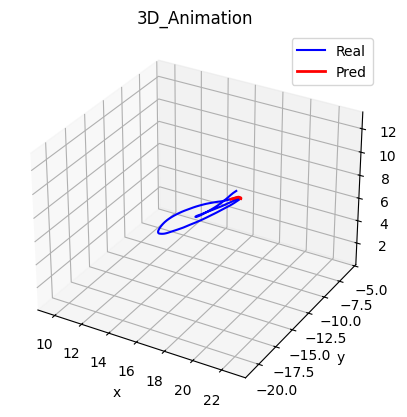

Total frames: 180


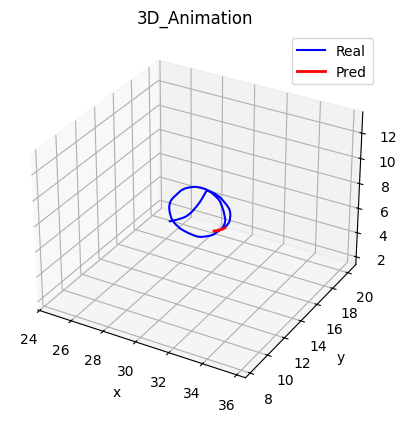

Total frames: 152


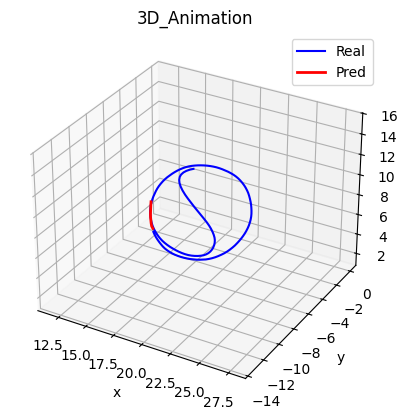

Total frames: 106


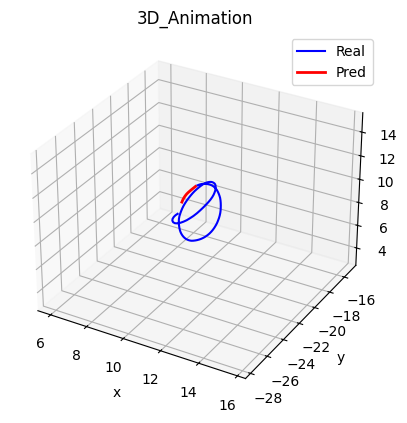

Total frames: 141


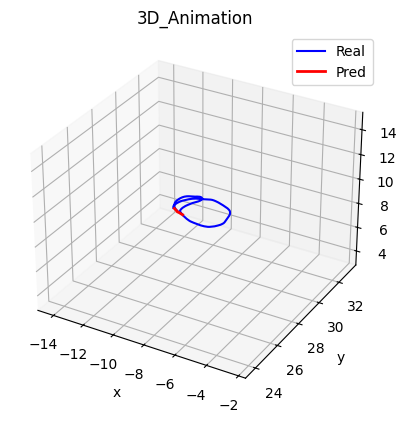

Total frames: 106


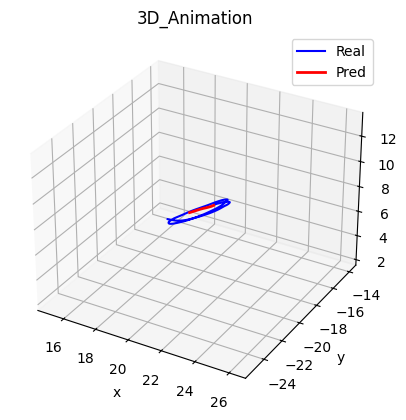

Total frames: 100


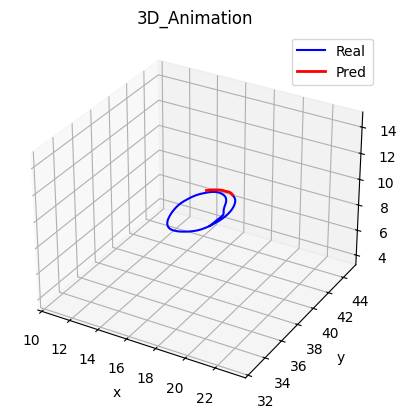

Total frames: 105


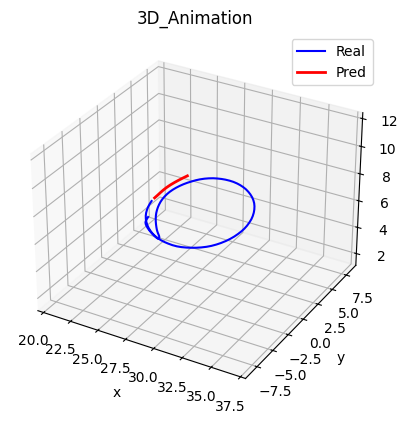

Total frames: 100


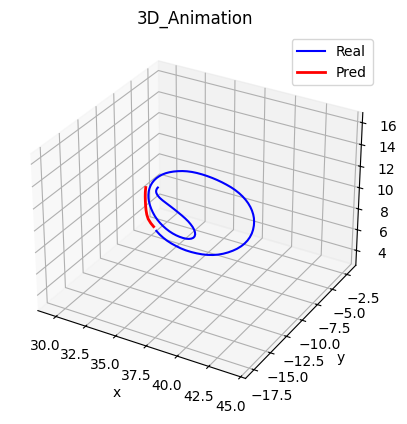

Total frames: 99


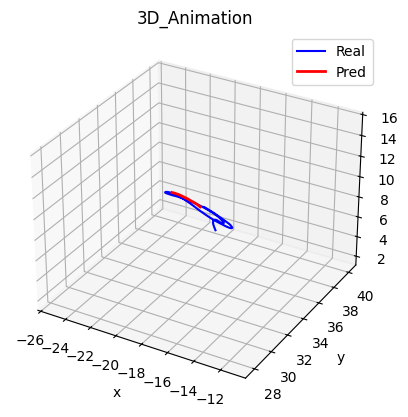

Total frames: 157


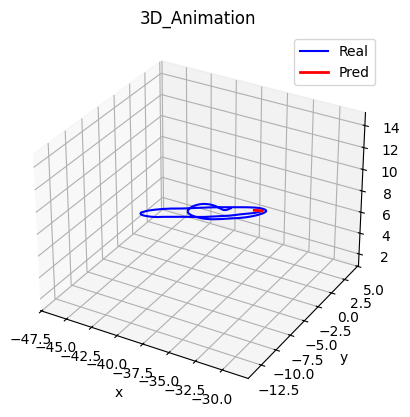

Total frames: 100


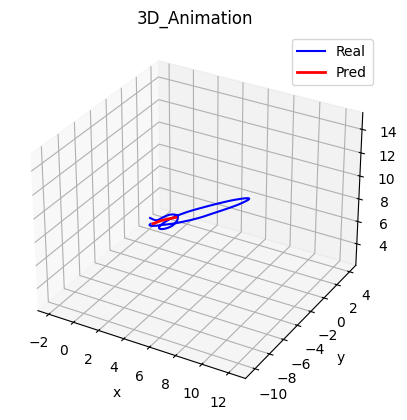

Total frames: 118


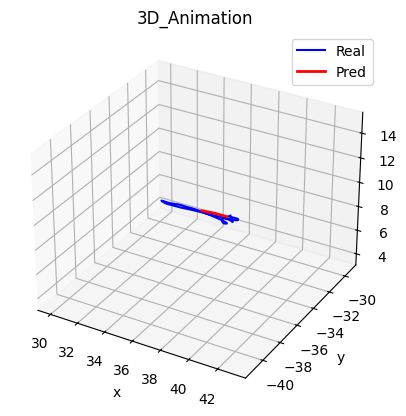

Total frames: 169


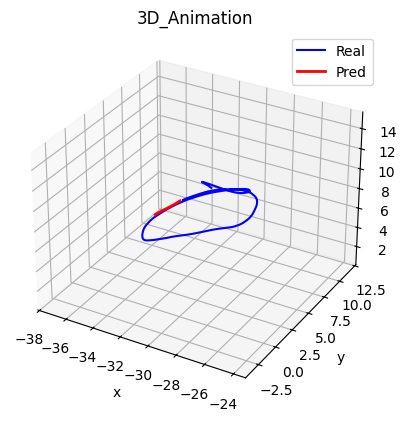

Total frames: 119


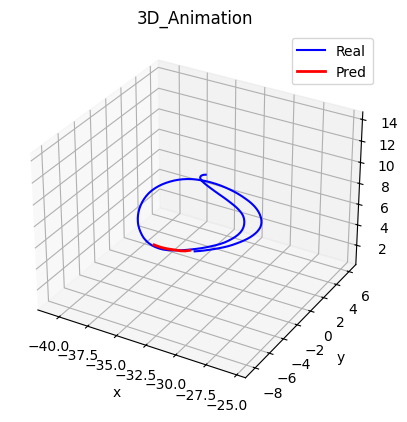

In [9]:
test_start_idx = len(circular) - test_num
for i in range(test_num):
    dataset1=circular[i+test_start_idx]
    dataset2=mutil_steps_pred[i]
    animation_double(i,dataset1,dataset2)